In [17]:
import torch

# Check CUDA availability
print(f"Is CUDA available? {torch.cuda.is_available()}")

# Check the number of CUDA devices
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

# Get the name of the GPU (if available)
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU found.")

Is CUDA available? True
Number of CUDA devices: 1
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


Using device: cuda
Epoch 1, Train Loss: 0.6703, Val Loss: 0.4360, Val Acc: 80.21%, Time: 244.93s
Validation loss decreased (inf --> 0.436021). Saving model ...
Epoch 2, Train Loss: 0.3299, Val Loss: 0.3095, Val Acc: 86.27%, Time: 238.44s
Validation loss decreased (0.436021 --> 0.309541). Saving model ...
Epoch 3, Train Loss: 0.2117, Val Loss: 0.3001, Val Acc: 87.96%, Time: 243.56s
Validation loss decreased (0.309541 --> 0.300089). Saving model ...
Epoch 4, Train Loss: 0.1341, Val Loss: 0.3238, Val Acc: 87.92%, Time: 248.19s
EarlyStopping counter: 1 out of 5
Epoch 5, Train Loss: 0.0721, Val Loss: 0.3492, Val Acc: 87.81%, Time: 241.48s
EarlyStopping counter: 2 out of 5
Epoch 6, Train Loss: 0.0483, Val Loss: 0.4605, Val Acc: 87.63%, Time: 246.91s
EarlyStopping counter: 3 out of 5
Epoch 7, Train Loss: 0.0339, Val Loss: 0.5064, Val Acc: 87.95%, Time: 246.37s
EarlyStopping counter: 4 out of 5
Epoch 8, Train Loss: 0.0284, Val Loss: 0.5278, Val Acc: 87.47%, Time: 241.97s
EarlyStopping counter:

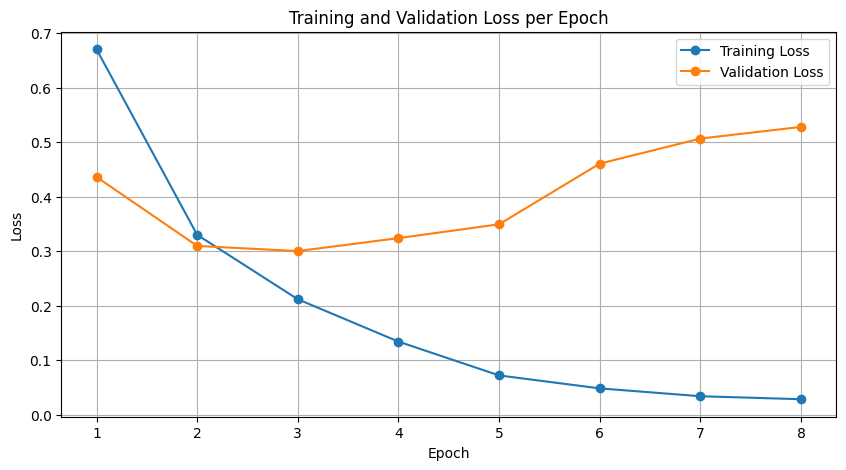

C:\Users\kgoel\AppData\Local\Temp\ipykernel_25880\2272819789.py:189: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("checkpoint.pth"))


Test Accuracy: 88.39%


In [18]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset_path = r"C:\Users\kgoel\Downloads\archive\IMDBDataset.csv"
df = pd.read_csv(dataset_path)
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
max_len = 256

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        tokens = self.tokenizer.encode(text, truncation=True, padding="max_length", max_length=self.max_len)
        return torch.tensor(label, dtype=torch.float32), torch.tensor(tokens)

texts = df['review'].tolist()
labels = df['sentiment'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(texts, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

train_dataset = IMDBDataset(X_train, y_train, tokenizer, max_len)
val_dataset = IMDBDataset(X_val, y_val, tokenizer, max_len)
test_dataset = IMDBDataset(X_test, y_test, tokenizer, max_len)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, num_layers=2, dropout=0.5):
        super(RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.embedding(text)
        output, hidden = self.rnn(embedded)
        hidden = self.dropout(hidden[-1])
        return self.fc(hidden)

vocab_size = tokenizer.vocab_size
embed_dim = 128
hidden_dim = 256
output_dim = 1
num_layers = 2

model = RNNModel(vocab_size, embed_dim, hidden_dim, output_dim, num_layers).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        print(f"Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model ...")
        torch.save(model.state_dict(), "checkpoint.pth")
        self.val_loss_min = val_loss

early_stopping = EarlyStopping(patience=5, verbose=True)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, early_stopping):
    train_losses = []
    val_losses = []
    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        for labels, texts in train_loader:
            labels, texts = labels.to(device), texts.to(device)
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for labels, texts in val_loader:
                labels, texts = labels.to(device), texts.to(device)
                outputs = model(texts)
                loss = criterion(outputs.squeeze(), labels)
                val_loss += loss.item()
                preds = torch.sigmoid(outputs).cpu().numpy()
                preds = (preds >= 0.5).astype(int)
                correct += (preds.flatten() == labels.cpu().numpy()).sum()
                total += labels.size(0)
        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)
        val_acc = 100 * correct / total
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Time: {epoch_time:.2f}s")

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping")
            break
    return train_losses, val_losses

EPOCHS = 15
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, EPOCHS, early_stopping)

epochs_range = range(1, len(train_losses) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, marker="o", linestyle="-", label="Training Loss")
plt.plot(epochs_range, val_losses, marker="o", linestyle="-", label="Validation Loss")
plt.title("Training and Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for labels, texts in test_loader:
            labels, texts = labels.to(device), texts.to(device)
            outputs = model(texts)
            preds = torch.sigmoid(outputs).cpu().numpy()
            preds = (preds >= 0.5).astype(int)
            correct += (preds.flatten() == labels.cpu().numpy()).sum()
            total += labels.size(0)
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.cpu().numpy())
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels

model.load_state_dict(torch.load("checkpoint.pth"))
test_preds, test_labels = evaluate_model(model, test_loader)



 3 Σωστές Προβλέψεις:

Review: Eleven "great" filmmakers, eleven pieces of garbage. Eleven minutes each of sheer tedium, sophistry, condescension, self-indulgence. Treats for people of all nations. Yussef Chahine of Egypt giving a "hip hip hooray!" for terorism in his amateurish segment. Across the green line we have Amos Gitai o...
Prediction: 0, Label: 0.0

Review: I was intrigued by the nasty boss character as I am one myself, and the actual boss's daughter was attractive and it was interesting to see an even younger Ashton Kushner, but this movie is so puerile I had to turn it off. It was a waste of time to watch it. When people started peeing all over the l...
Prediction: 0, Label: 0.0

Review: "Problem Child" is one of the goofiest movies ever made. It's not the worst (though some people will disagree with me on that), but it's not the best either. It's about a devilish 7-year-old boy who wrecks comic havoc on a childless couple (John Ritter, Amy Yasbeck) who foolishly adopts hi

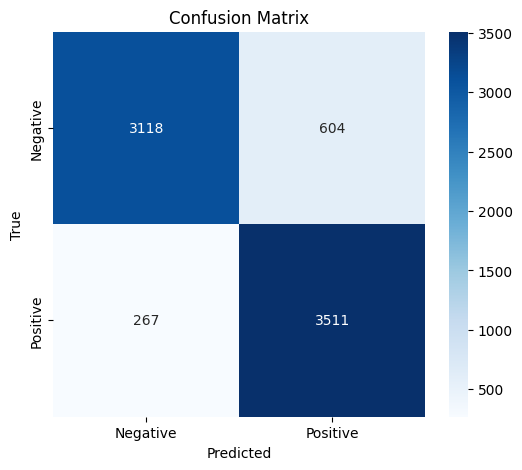


Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.84      0.88      3722
    Positive       0.85      0.93      0.89      3778

    accuracy                           0.88      7500
   macro avg       0.89      0.88      0.88      7500
weighted avg       0.89      0.88      0.88      7500



In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

test_texts = X_test  
test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

correct_indices = np.where(test_preds == test_labels)[0]
incorrect_indices = np.where(test_preds != test_labels)[0]

print("\n 3 Σωστές Προβλέψεις:")
for idx in correct_indices[:3]:
    print(f"\nReview: {test_texts[idx][:300]}...")
    print(f"Prediction: {test_preds[idx]}, Label: {test_labels[idx]}")

print("\n 3 Λάθος Προβλέψεις:")
for idx in incorrect_indices[:3]:
    print(f"\nReview: {test_texts[idx][:300]}...")
    print(f"Prediction: {test_preds[idx]}, Label: {test_labels[idx]}")

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Negative', 'Positive']))


Using device: cuda
Epoch 1, Train Loss: 0.6943, Val Loss: 0.6940, Val Acc: 49.19%, Time: 226.38s
Validation loss decreased (inf --> 0.693995). Saving model ...
Epoch 2, Train Loss: 0.6923, Val Loss: 0.6897, Val Acc: 55.01%, Time: 221.21s
Validation loss decreased (0.693995 --> 0.689709). Saving model ...
Epoch 3, Train Loss: 0.6644, Val Loss: 0.6946, Val Acc: 50.81%, Time: 224.56s
EarlyStopping counter: 1 out of 5
Epoch 4, Train Loss: 0.6457, Val Loss: 0.4992, Val Acc: 77.27%, Time: 219.12s
Validation loss decreased (0.689709 --> 0.499221). Saving model ...
Epoch 5, Train Loss: 0.4187, Val Loss: 0.3626, Val Acc: 82.97%, Time: 221.38s
Validation loss decreased (0.499221 --> 0.362619). Saving model ...
Epoch 6, Train Loss: 0.3041, Val Loss: 0.3201, Val Acc: 87.08%, Time: 218.97s
Validation loss decreased (0.362619 --> 0.320125). Saving model ...
Epoch 7, Train Loss: 0.2454, Val Loss: 0.3166, Val Acc: 86.83%, Time: 218.72s
Validation loss decreased (0.320125 --> 0.316555). Saving model ..

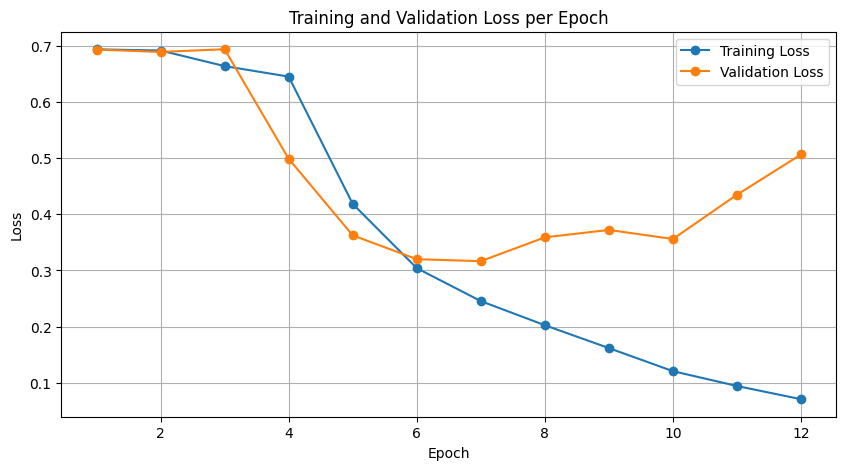

Test Accuracy: 86.81%


In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset_path = r"C:\Users\kgoel\Downloads\archive\IMDBDataset.csv"
df = pd.read_csv(dataset_path)
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
max_len = 256

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        tokens = self.tokenizer.encode(text, truncation=True, padding="max_length", max_length=self.max_len)
        return torch.tensor(label, dtype=torch.float32), torch.tensor(tokens)

texts = df['review'].tolist()
labels = df['sentiment'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(texts, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

train_dataset = IMDBDataset(X_train, y_train, tokenizer, max_len)
val_dataset = IMDBDataset(X_val, y_val, tokenizer, max_len)
test_dataset = IMDBDataset(X_test, y_test, tokenizer, max_len)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, num_layers=2, dropout=0.5):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)
        hidden = self.dropout(hidden[-1])
        return self.fc(hidden)

vocab_size = tokenizer.vocab_size
embed_dim = 128
hidden_dim = 256
output_dim = 1
num_layers = 2

model = LSTMModel(vocab_size, embed_dim, hidden_dim, output_dim, num_layers).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        print(f"Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model ...")
        torch.save(model.state_dict(), "checkpoint.pth")
        self.val_loss_min = val_loss

early_stopping = EarlyStopping(patience=5, verbose=True)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, early_stopping):
    train_losses = []
    val_losses = []
    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        for labels, texts in train_loader:
            labels, texts = labels.to(device), texts.to(device)
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for labels, texts in val_loader:
                labels, texts = labels.to(device), texts.to(device)
                outputs = model(texts)
                loss = criterion(outputs.squeeze(), labels)
                val_loss += loss.item()
                preds = torch.sigmoid(outputs).cpu().numpy()
                preds = (preds >= 0.5).astype(int)
                correct += (preds.flatten() == labels.cpu().numpy()).sum()
                total += labels.size(0)
        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)
        val_acc = 100 * correct / total
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Time: {epoch_time:.2f}s")

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping")
            break
    return train_losses, val_losses

EPOCHS = 15
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, EPOCHS, early_stopping)

epochs_range = range(1, len(train_losses) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, marker="o", linestyle="-", label="Training Loss")
plt.plot(epochs_range, val_losses, marker="o", linestyle="-", label="Validation Loss")
plt.title("Training and Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for labels, texts in test_loader:
            labels, texts = labels.to(device), texts.to(device)
            outputs = model(texts)
            preds = torch.sigmoid(outputs).cpu().numpy()
            preds = (preds >= 0.5).astype(int)
            correct += (preds.flatten() == labels.cpu().numpy()).sum()
            total += labels.size(0)
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.cpu().numpy())
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels

model.load_state_dict(torch.load("checkpoint.pth", weights_only=True))
test_preds, test_labels = evaluate_model(model, test_loader)



 3 Σωστές Προβλέψεις:

Review: Eleven "great" filmmakers, eleven pieces of garbage. Eleven minutes each of sheer tedium, sophistry, condescension, self-indulgence. Treats for people of all nations. Yussef Chahine of Egypt giving a "hip hip hooray!" for terorism in his amateurish segment. Across the green line we have Amos Gitai o...
Prediction: 0, Label: 0.0

Review: I was intrigued by the nasty boss character as I am one myself, and the actual boss's daughter was attractive and it was interesting to see an even younger Ashton Kushner, but this movie is so puerile I had to turn it off. It was a waste of time to watch it. When people started peeing all over the l...
Prediction: 0, Label: 0.0

Review: "Problem Child" is one of the goofiest movies ever made. It's not the worst (though some people will disagree with me on that), but it's not the best either. It's about a devilish 7-year-old boy who wrecks comic havoc on a childless couple (John Ritter, Amy Yasbeck) who foolishly adopts hi

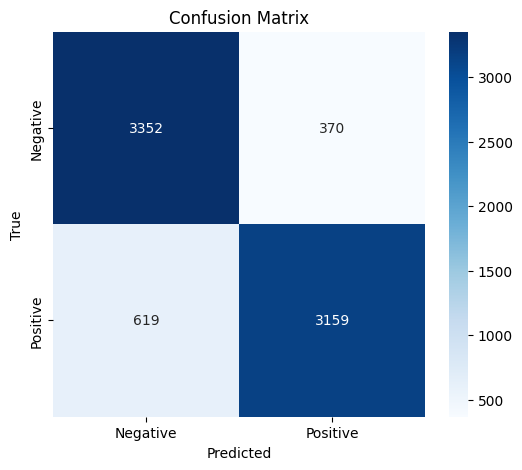


Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.90      0.87      3722
    Positive       0.90      0.84      0.86      3778

    accuracy                           0.87      7500
   macro avg       0.87      0.87      0.87      7500
weighted avg       0.87      0.87      0.87      7500



In [2]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_texts = X_test  # Αν έχεις κρατήσει τα κείμενα του test set
test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

correct_indices = np.where(test_preds == test_labels)[0]
incorrect_indices = np.where(test_preds != test_labels)[0]

print("\n 3 Σωστές Προβλέψεις:")
for idx in correct_indices[:3]:
    print(f"\nReview: {test_texts[idx][:300]}...")
    print(f"Prediction: {test_preds[idx]}, Label: {test_labels[idx]}")

print("\n 3 Λανθασμένες Προβλέψεις:")
for idx in incorrect_indices[:3]:
    print(f"\nReview: {test_texts[idx][:300]}...")
    print(f"Prediction: {test_preds[idx]}, Label: {test_labels[idx]}")

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Negative', 'Positive']))


Using device: cuda
Epoch 1, Train Loss: 1.1127, Val Loss: 1.0972, Val Acc: 39.09%, Time: 269.31s
Validation loss decreased (inf --> 1.097239). Saving model ...
Epoch 2, Train Loss: 0.9989, Val Loss: 0.9555, Val Acc: 54.12%, Time: 247.65s
Validation loss decreased (1.097239 --> 0.955490). Saving model ...
Epoch 3, Train Loss: 0.7684, Val Loss: 0.8997, Val Acc: 58.56%, Time: 246.69s
Validation loss decreased (0.955490 --> 0.899670). Saving model ...
Epoch 4, Train Loss: 0.6438, Val Loss: 0.9464, Val Acc: 57.96%, Time: 244.48s
EarlyStopping counter: 1 out of 5
Epoch 5, Train Loss: 0.5123, Val Loss: 1.0987, Val Acc: 57.25%, Time: 246.09s
EarlyStopping counter: 2 out of 5
Epoch 6, Train Loss: 0.3671, Val Loss: 1.2871, Val Acc: 55.13%, Time: 244.56s
EarlyStopping counter: 3 out of 5
Epoch 7, Train Loss: 0.2396, Val Loss: 1.6968, Val Acc: 54.72%, Time: 243.02s
EarlyStopping counter: 4 out of 5
Epoch 8, Train Loss: 0.1566, Val Loss: 1.9805, Val Acc: 53.11%, Time: 244.43s
EarlyStopping counter:

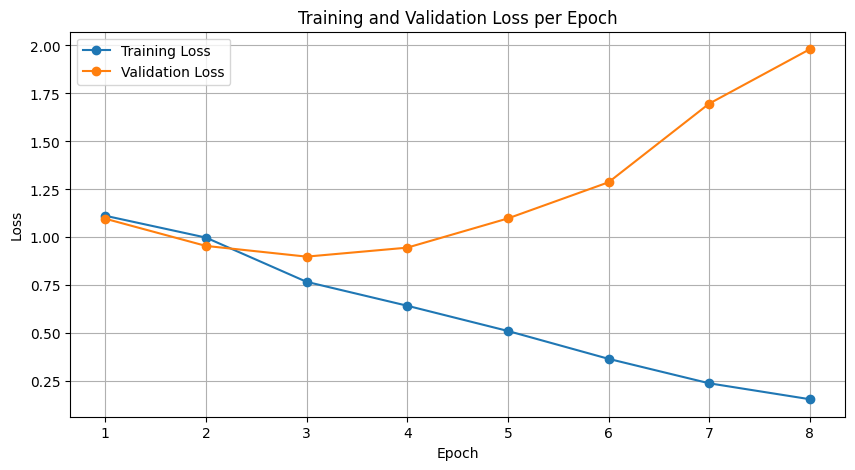

In [13]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import BertTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_path = r"C:\Users\kgoel\Downloads\imdbdataset\train.tsv"
test_path = r"C:\Users\kgoel\Downloads\imdbdataset\test.tsv"

train_df = pd.read_csv(train_path, sep='\t')
test_df = pd.read_csv(test_path, sep='\t')

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
max_len = 256

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        tokens = self.tokenizer.encode(text, truncation=True, padding="max_length", max_length=self.max_len)
        return torch.tensor(tokens, dtype=torch.long), torch.tensor(label, dtype=torch.long)

train_dataset = IMDBDataset(train_df['review'].tolist(), train_df['sentiment'].tolist(), tokenizer, max_len)
test_dataset = IMDBDataset(test_df['review'].tolist(), test_df['sentiment'].tolist(), tokenizer, max_len)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, num_layers=2, dropout=0.5):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.embedding(text)
        output, hidden = self.gru(embedded)
        hidden = self.dropout(hidden[-1])
        return self.fc(hidden)

vocab_size = tokenizer.vocab_size
embed_dim = 128
hidden_dim = 256
output_dim = 3  # 3 classes: negative, neutral, positive

model = GRUModel(vocab_size, embed_dim, hidden_dim, output_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        print(f"Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model ...")
        torch.save(model.state_dict(), "checkpoint.pth")
        self.val_loss_min = val_loss

early_stopping = EarlyStopping(patience=5, verbose=True)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, early_stopping):
    train_losses = []
    val_losses = []
    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device)
                outputs = model(texts)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                correct += (preds == labels.cpu().numpy()).sum()
                total += labels.size(0)
        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)
        val_acc = 100 * correct / total
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Time: {epoch_time:.2f}s")

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping")
            break
    return train_losses, val_losses

EPOCHS = 15
train_losses, val_losses = train_model(model, train_loader, test_loader, criterion, optimizer, EPOCHS, early_stopping)

epochs_range = range(1, len(train_losses) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, marker="o", linestyle="-", label="Training Loss")
plt.plot(epochs_range, val_losses, marker="o", linestyle="-", label="Validation Loss")
plt.title("Training and Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
